Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
SIMPLE            = True
BITPIX            = 16
NAXIS             = 2
NAXIS1            = 530
NAXIS2            = 530
(530, 530)
>i2
N=280900 min=1507, max=15752, mean=4795.924268422927, std=1848.2558984219054
3551 876
Mode of the data: 3551 with 876 counts
Median of the data: 4102.0


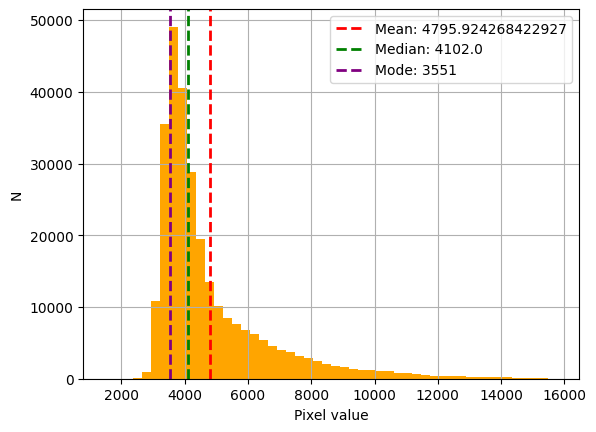

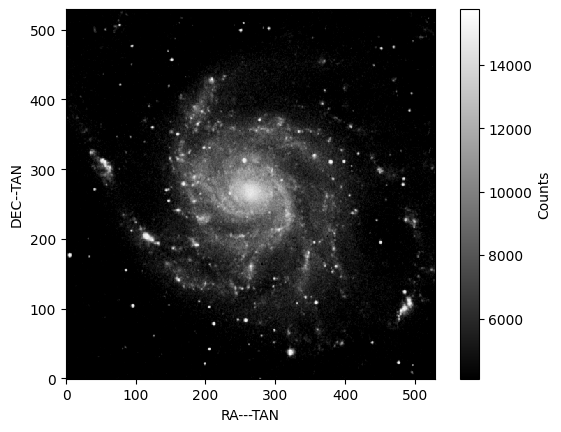

 [astropy.io.fits.verify]


In [1]:
from astropy.io import fits
import numpy as np
from scipy import stats

datafile=fits.open('m101.fits')
datafile.info()
# 2 HDUs
# PrimaryHDU with index 0
# number type: int16

hdr = datafile[0].header
for key in hdr[:5]:
    print(f"{key:18s}= {hdr[key]}")

dat = datafile[0].data
print(dat.shape)
print(dat.dtype)
# dtype defines the type of data stored in an array and how much memory each value uses.
# >i2 is signed 2-byte integer and corresponds to bitpix

flatdat = dat.flatten()
s = stats.describe(flatdat)

mode = stats.mode(dat.flat)


nobs, (minval, maxval), mean, var, skew, kurt = stats.describe(dat.flat)
print(f"N={nobs} min={minval}, max={maxval}, mean={mean}, std={var**0.5}")

mode, counts = stats.mode(dat.flat)
print(mode, counts)
print(f"Mode of the data: {mode} with {counts} counts")

median = np.median(dat.flat)
print(f"Median of the data: {median}")

# 6
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.hist(flatdat, bins=50, color="orange")
frame.grid()
frame.set_xlabel("Pixel value")
frame.set_ylabel("N")
plt.axvline(mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean}')
plt.axvline(median, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median}')
plt.axvline(mode, color='purple', linestyle='dashed', linewidth=2, label=f'Mode: {mode}')
plt.legend()
plt.show()

ctype1 = hdr['CTYPE1']
ctype2 = hdr['CTYPE2']

dat_float = np.asarray(dat, dtype=np.float32)

plt.imshow(dat_float,  interpolation='none',cmap='gray', origin='lower', vmin=np.median(dat_float))
plt.xlabel(ctype1)
plt.ylabel(ctype2)
plt.colorbar(label="Counts")
plt.show()

hdr["BUNIT"]="Counts"

newfit = fits.PrimaryHDU(dat_float)
newfit.header = hdr    # We can copy the old header
newfit.writeto('newFIT.fits', overwrite=True, output_verify='ignore')

datafile.close()

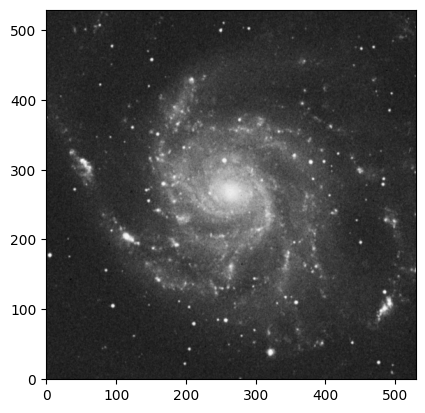

RMS=  271.89124664100535
3422.8825 260.1300322795313


In [2]:
from astropy.io import fits
import numpy as np

datafile=fits.open('m101.fits')

dat = datafile[0].data
plt.imshow(dat, cmap='gray', origin='lower')
plt.show()

cutout = dat[0:20, 0:20]
RMS=np.sqrt(np.sum(cutout**2)/len(cutout))
print('RMS= ', RMS)
mean = np.mean(cutout)
std = np.std(cutout)
print(mean, std)
# std relative to the mean and rms is relative to 0
# std is better because it is relative to the mean and rms also contains the actual signal in its value
datafile.close()

In [3]:
from astropy.io import fits
import numpy as np

hdul0=fits.open('noisemap0.fits')
hdul1=fits.open('noisemap1.fits')
hdul2=fits.open('noisemap2.fits')

dat0 = hdul0[0].data
dat1 = hdul1[0].data
dat2 = hdul2[0].data

std0 = np.std(dat0)
std1 = np.std(dat1)
std2 = np.std(dat2)
print(std0, std1, std2)
stack = np.stack([dat0,dat1,dat2], axis = 0)
mean_image = np.mean(stack, axis=0) 
std_mean_image = np.std(mean_image)
print(std_mean_image)

std_calculated = np.sqrt(std0**2+std1**2+std2**2)/3
print(std_calculated)

9.98401556679484 10.003955116338458 9.995349488722516
5.773191380233297
5.77029458336614


In [44]:
from astropy.io import fits
from astropy.table import QTable
import numpy as np

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
print(colnames)
print(data)

#create table

data = QTable(data)

# difference from image: Table has to read from index 1 and image from 0.
# Table has columns with different data. Image has one 2/3D array with data.

mask = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

DATAFLAG = np.where(mask,1,0)

data['DATAFLAG']= DATAFLAG

parallax = data['GAIAEDR3_PARALLAX']
m_G = data['GAIAEDR3_PHOT_G_MEAN_MAG']
mask2 = ((parallax>0) & (~np.isnan(parallax)))


parallax2 = np.where(mask2, parallax, 1000)
M_G= np.where(mask2, m_G + 5*np.log10(parallax2/1000) + 5, 'None')
abs_M=np.where(data['DATAFLAG']==1, M_G, -1.0)
data['ABS_MAGN'] = abs_M

data.write('APOGEE_update.fits', overwrite = True)
print(data)

open1 = fits.open('APOGEE_update.fits')
dat = open1[1].data  
colname = open1[1].columns.names
print(colname)
print(dat)

['GAIAEDR3_PARALLAX', 'GAIAEDR3_PARALLAX_ERROR', 'GAIAEDR3_PHOT_G_MEAN_MAG', 'GAIAEDR3_PHOT_BP_MEAN_MAG', 'GAIAEDR3_PHOT_RP_MEAN_MAG', 'ASPCAPFLAG', 'STARFLAG', 'SNR']
[(       nan,       nan,     nan,     nan,     nan, 133,    0, 418.9276  )
 (0.28544167, 0.019475 , 11.6988, 13.2722, 10.4956,   0, 3072, 827.1565  )
 (0.08209286, 0.315081 , 12.2882, 12.5149, 11.6597,  68,    0, 229.87506 )
 ...
 (0.33459017, 0.0153441, 13.9818, 14.7112, 13.1544,   0, 2052, 130.77075 )
 (0.01822683, 0.0693144, 17.5628, 18.1846, 16.8085,   0,    0,  33.586742)
 (2.0103858 , 0.0225479, 11.6622, 11.9146, 11.2472,  64,  516, 209.74567 )]
GAIAEDR3_PARALLAX GAIAEDR3_PARALLAX_ERROR ... DATAFLAG  ABS_MAGN
----------------- ----------------------- ... -------- ---------
              nan                     nan ...        0      -1.0
       0.28544167                0.019475 ...        0      -1.0
       0.08209286                0.315081 ...        0      -1.0
        1.2985312              0.00952245 ...      

Max flux: 42489404.0
    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  


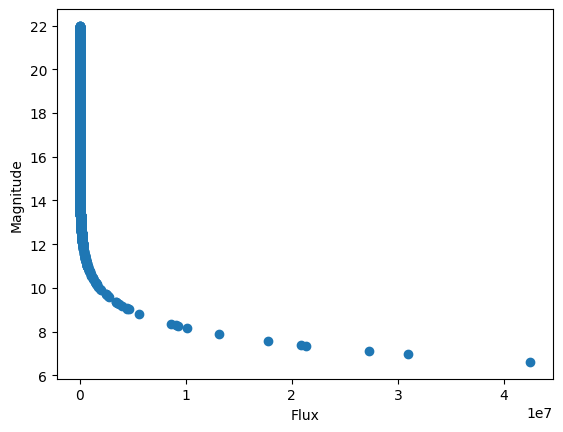

25.68840037029544


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('gaiaTestData.csv') # creating the dataframe

max_flux = df['phot_g_mean_flux'].max()
print("Max flux:", max_flux)

# row with max
max_row = df[df['phot_g_mean_flux'] == max_flux]
print(max_row)

df_sorted = df.sort_values(by='phot_g_mean_flux') # to sort by column

fig, frame = plt.subplots()

frame.scatter(df_sorted['phot_g_mean_flux'], df_sorted['phot_g_mean_mag']) # making scatter plot

frame.set_xlabel('Flux')
frame.set_ylabel('Magnitude')

plt.show()

# calculating the m0
m0 = df['phot_g_mean_mag'] + 2.5 * np.log10(df['phot_g_mean_flux'])
m0_avg = m0.mean()
print(m0_avg)

In [10]:
from astroquery.gaia import Gaia
import pandas as pd
from astropy.io import fits

query = """
SELECT TOP 50 source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiaedr3.gaia_source
WHERE parallax / parallax_error > 5
  AND phot_g_mean_mag IS NOT NULL
  AND phot_bp_mean_mag IS NOT NULL
  AND phot_rp_mean_mag IS NOT NULL
ORDER BY RANDOM_INDEX
"""

job = Gaia.launch_job(query)
results = job.get_results()

df = results.to_pandas()
results.write("astroquery_gaia.fits", overwrite = True)

In [27]:
from astroquery.gaia import Gaia
import pandas as pd
from astropy.io import fits

hdul = fits.open("astroquery_gaia.fits")
dat = hdul[1].data
print(dat)

[(5208927304275007488, 121.16595723, -78.96801918, 3.17501095, 0.01375507, 11.387156, 11.779815, 10.826169)
 (3479127713981703040, 176.86059268, -32.0414922 , 0.61337968, 0.03691787, 15.773158, 16.202496, 15.176801)
 ( 389020824661572352,   8.44706248,  45.35233689, 6.02028611, 0.01981839, 11.086079, 11.445748, 10.560516)
 (4106836497175936256, 281.52393452, -11.15993878, 0.70650349, 0.03124247, 15.256926, 15.756729, 14.587771)
 (5952545843004105856, 262.18525892, -44.27011567, 7.88839249, 1.1095833 , 19.94762 , 20.16205 , 18.487116)
 (2006009834767249024, 334.90000609,  55.77418386, 0.5477643 , 0.05638528, 16.881334, 17.426413, 16.150646)
 (5856294805570279552, 185.44301725, -68.51132111, 0.46546786, 0.03397143, 16.004335, 16.405127, 15.421232)
 (1978981811726607616, 325.29544494,  49.4511248 , 0.40904546, 0.04128516, 16.54717 , 17.184631, 15.76654 )
 (5704809109985676544, 133.72390384, -19.11418752, 0.28312488, 0.02682308, 15.101916, 15.504135, 14.518418)
 (5864939921966143616, 202.0

In [36]:
class Fibonacci:
    """Class for calculating Fibonacci sequence"""
    def __init__(self,N,M):
        self.N=N
        self.M=M
        
    def fibo(self):
        """ Return the Fibonacci numbers less than N that can be divided by M.
        This function is written by dmeindertsma on 25-02-2026.
        Parameters: N,M
        """
# Fibonacci sequence less than N
    
        x=[0,1]
        while len(x)< self.N:
            x.append(x[-2]+x[-1])
        
# Numbers that can be divided by M
    
        result=[]
        for value in x:
            if value%self.M==0:
                result.append(value)
        return result

    def nth_term(self):
        """
        Return the N-th Fibonacci number (0-indexed)
        """
        x = [0, 1]
        while len(x) < self.N:
            x.append(x[-2] + x[-1])
        return x[-1]  # N-th term
    
fib = Fibonacci(N=100, M=7)

# N-th term
print("100th Fibonacci number:", fib.nth_term())

# Fibonacci numbers < N-th term divisible by 7
print("Fibonacci numbers divisible by 7:", fib.fibo())

100th Fibonacci number: 218922995834555169026
Fibonacci numbers divisible by 7: [0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
